# Generative AI – Assignment 03
## Question 2 – CIFAR-10 Image Classification with ViT, CNN, and ResNet

This Colab-ready notebook implements three architectures on the CIFAR-10 dataset:
- A **Vision Transformer (ViT) from scratch-style** (patch embedding + Transformer encoder)
- A **baseline CNN + MLP classifier**
- A **Transfer Learning model using ResNet-18 pretrained on ImageNet**

For each model we will:
- Train and validate on CIFAR-10
- Plot training & validation loss and accuracy curves
- Evaluate on the test set (accuracy, precision, recall, F1, confusion matrix)
- Compare performance, speed, and parameter counts
- Provide a simple Gradio UI for interactive predictions.

In [1]:

# =====================================
# Cell 1: Setup, installs, and imports
# =====================================

!pip install -q torch torchvision torchaudio scikit-learn gradio

import os
import time
import math
from typing import Tuple, List, Dict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import gradio as gr

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
torch.__version__, torchvision.__version__


Using device: cuda


('2.9.0+cu126', '0.24.0+cu126')

## 1. CIFAR-10 Dataset & Data Loaders

We download CIFAR-10 and create train/validation/test splits with standard augmentation.

In [3]:

# =====================================
# Cell 2: Define transforms and load CIFAR-10
# =====================================

# CIFAR-10 normalization stats
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

data_root = "./data"

full_train_dataset = datasets.CIFAR10(
    root=data_root,
    train=True,
    download=True,
    transform=train_transform,
)

test_dataset = datasets.CIFAR10(
    root=data_root,
    train=False,
    download=True,
    transform=test_transform,
)

num_train = len(full_train_dataset)
val_ratio = 0.1
num_val = int(num_train * val_ratio)
num_train = num_train - num_val

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [num_train, num_val],
    generator=torch.Generator().manual_seed(42),
)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = full_train_dataset.classes
print("Classes:", class_names)
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 45000, Val: 5000, Test: 10000


## 2. Training & Evaluation Utilities

We define helper functions to train a model, evaluate on validation/test sets, and compute metrics.

In [4]:

# =====================================
# Cell 3: Training and evaluation helpers
# =====================================

def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        _, preds = torch.max(outputs, 1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc

def eval_model(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += inputs.size(0)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

def compute_metrics(y_true, y_pred, num_classes=10):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    return acc, precision, recall, f1, cm


## 3. Baseline CNN + MLP Model

We start with a simple convolutional neural network followed by fully connected layers as a baseline.

In [5]:

# =====================================
# Cell 4: CNN + MLP classifier
# =====================================

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_model = SimpleCNN(num_classes=10).to(device)
print("SimpleCNN parameters:", count_parameters(cnn_model))


SimpleCNN parameters: 620810


In [6]:

# =====================================
# Cell 5: Train CNN baseline
# =====================================

N_EPOCHS_CNN = 5  # increase if you have more time
LR_CNN = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.Adam(cnn_model.parameters(), lr=LR_CNN)

history_cnn = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "epoch_time": [],
}

for epoch in range(1, N_EPOCHS_CNN + 1):
    start = time.time()
    train_loss, train_acc = train_one_epoch(cnn_model, train_loader, optimizer_cnn, criterion)
    val_loss, val_acc, _, _ = eval_model(cnn_model, val_loader, criterion)

    history_cnn["train_loss"].append(train_loss)
    history_cnn["train_acc"].append(train_acc)
    history_cnn["val_loss"].append(val_loss)
    history_cnn["val_acc"].append(val_acc)
    history_cnn["epoch_time"].append(time.time() - start)

    print(
        f"[CNN] Epoch {epoch}/{N_EPOCHS_CNN} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
        f"Time: {history_cnn['epoch_time'][-1]:.1f}s"
    )


[CNN] Epoch 1/5 | Train Loss: 1.6348, Train Acc: 0.3968 | Val Loss: 1.3571, Val Acc: 0.5096 | Time: 20.0s
[CNN] Epoch 2/5 | Train Loss: 1.3078, Train Acc: 0.5277 | Val Loss: 1.1532, Val Acc: 0.5856 | Time: 17.4s
[CNN] Epoch 3/5 | Train Loss: 1.1721, Train Acc: 0.5834 | Val Loss: 1.0662, Val Acc: 0.6074 | Time: 19.1s
[CNN] Epoch 4/5 | Train Loss: 1.0810, Train Acc: 0.6164 | Val Loss: 0.9158, Val Acc: 0.6750 | Time: 17.7s
[CNN] Epoch 5/5 | Train Loss: 1.0221, Train Acc: 0.6394 | Val Loss: 0.8917, Val Acc: 0.6840 | Time: 17.7s


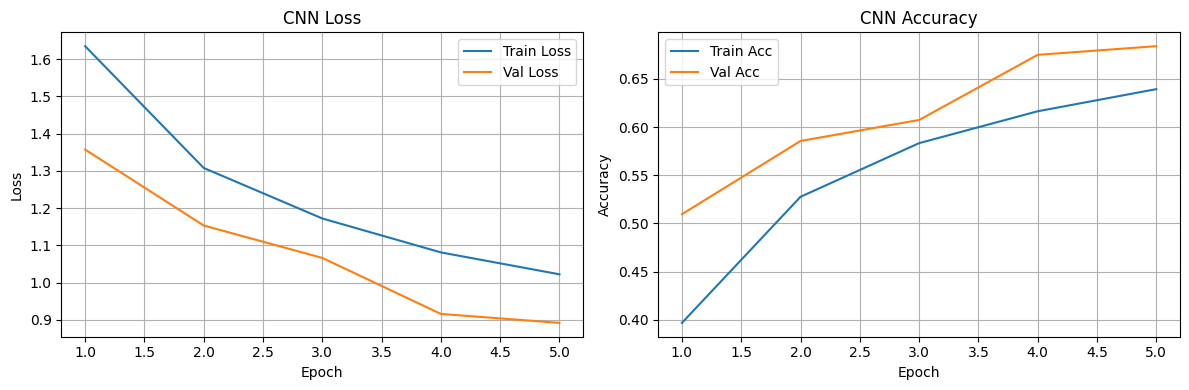

[CNN] Test Loss: 0.8287, Test Acc: 0.7113
[CNN] Metrics - Acc: 0.7113, Precision: 0.7116, Recall: 0.7113, F1: 0.7097

[CNN] Classification Report:
              precision    recall  f1-score   support

    airplane      0.764     0.710     0.736      1000
  automobile      0.877     0.811     0.843      1000
        bird      0.621     0.554     0.586      1000
         cat      0.516     0.531     0.523      1000
        deer      0.710     0.612     0.657      1000
         dog      0.595     0.629     0.612      1000
        frog      0.751     0.732     0.741      1000
       horse      0.758     0.779     0.768      1000
        ship      0.755     0.898     0.820      1000
       truck      0.769     0.857     0.811      1000

    accuracy                          0.711     10000
   macro avg      0.712     0.711     0.710     10000
weighted avg      0.712     0.711     0.710     10000



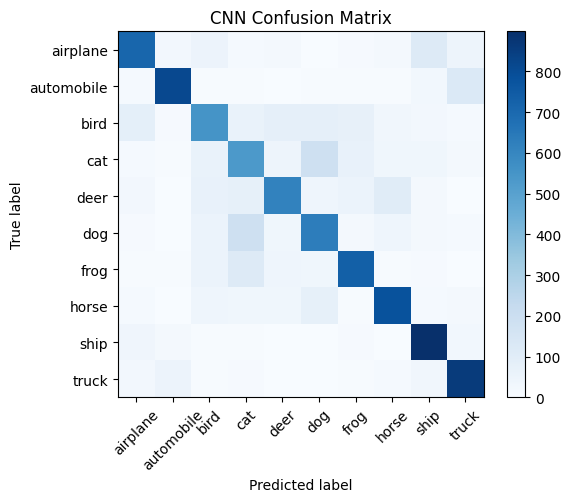

In [7]:

# =====================================
# Cell 6: CNN loss/accuracy plots and test metrics
# =====================================

def plot_history(history, title_prefix="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_cnn, title_prefix="CNN")

# Evaluate CNN on test set
test_loss_cnn, test_acc_cnn, y_true_cnn, y_pred_cnn = eval_model(cnn_model, test_loader, criterion)
acc_cnn, prec_cnn, rec_cnn, f1_cnn, cm_cnn = compute_metrics(y_true_cnn, y_pred_cnn, num_classes=10)

print(f"[CNN] Test Loss: {test_loss_cnn:.4f}, Test Acc: {test_acc_cnn:.4f}")
print(f"[CNN] Metrics - Acc: {acc_cnn:.4f}, Precision: {prec_cnn:.4f}, Recall: {rec_cnn:.4f}, F1: {f1_cnn:.4f}")

print("\n[CNN] Classification Report:")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names, digits=3))

plt.figure(figsize=(6, 5))
plt.imshow(cm_cnn, interpolation="nearest", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


## 4. Vision Transformer (ViT) Model

We now implement a simple Vision Transformer:
- Split 32×32 images into patches
- Linearly embed patches
- Add a learnable class token and positional embeddings
- Pass through Transformer encoder layers
- Use the class token for classification.

In [8]:

# =====================================
# Cell 7: Vision Transformer components
# =====================================

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=256):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) * (img_size // patch_size)
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)  # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)  # (B, embed_dim, N)
        x = x.transpose(1, 2)  # (B, N, embed_dim)
        return x

class ViT(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=256,
        depth=6,
        num_heads=8,
        mlp_dim=512,
        dropout=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)  # (B, N, D)

        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B, 1, D)
        x = torch.cat((cls_tokens, x), dim=1)  # (B, N+1, D)

        x = x + self.pos_embed
        x = self.pos_drop(x)

        x = self.transformer_encoder(x)  # (B, N+1, D)
        x = self.norm(x)
        cls_out = x[:, 0]  # class token
        logits = self.head(cls_out)
        return logits

vit_model = ViT(
    img_size=32,
    patch_size=4,
    in_channels=3,
    num_classes=10,
    embed_dim=256,
    depth=6,
    num_heads=8,
    mlp_dim=512,
    dropout=0.1,
).to(device)

print("ViT parameters:", count_parameters(vit_model))


ViT parameters: 3195146


In [9]:

# =====================================
# Cell 8: Train ViT model
# =====================================

N_EPOCHS_VIT = 5  # increase for better results
LR_VIT = 3e-4

optimizer_vit = torch.optim.AdamW(vit_model.parameters(), lr=LR_VIT, weight_decay=1e-4)
criterion_vit = nn.CrossEntropyLoss()

history_vit = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "epoch_time": [],
}

for epoch in range(1, N_EPOCHS_VIT + 1):
    start = time.time()
    train_loss, train_acc = train_one_epoch(vit_model, train_loader, optimizer_vit, criterion_vit)
    val_loss, val_acc, _, _ = eval_model(vit_model, val_loader, criterion_vit)

    history_vit["train_loss"].append(train_loss)
    history_vit["train_acc"].append(train_acc)
    history_vit["val_loss"].append(val_loss)
    history_vit["val_acc"].append(val_acc)
    history_vit["epoch_time"].append(time.time() - start)

    print(
        f"[ViT] Epoch {epoch}/{N_EPOCHS_VIT} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
        f"Time: {history_vit['epoch_time'][-1]:.1f}s"
    )


[ViT] Epoch 1/5 | Train Loss: 1.8187, Train Acc: 0.3159 | Val Loss: 1.6655, Val Acc: 0.3838 | Time: 37.7s
[ViT] Epoch 2/5 | Train Loss: 1.4571, Train Acc: 0.4655 | Val Loss: 1.3290, Val Acc: 0.5174 | Time: 39.8s
[ViT] Epoch 3/5 | Train Loss: 1.2643, Train Acc: 0.5423 | Val Loss: 1.2025, Val Acc: 0.5692 | Time: 37.9s
[ViT] Epoch 4/5 | Train Loss: 1.1629, Train Acc: 0.5824 | Val Loss: 1.1234, Val Acc: 0.5960 | Time: 38.2s
[ViT] Epoch 5/5 | Train Loss: 1.0886, Train Acc: 0.6073 | Val Loss: 1.0124, Val Acc: 0.6326 | Time: 38.2s


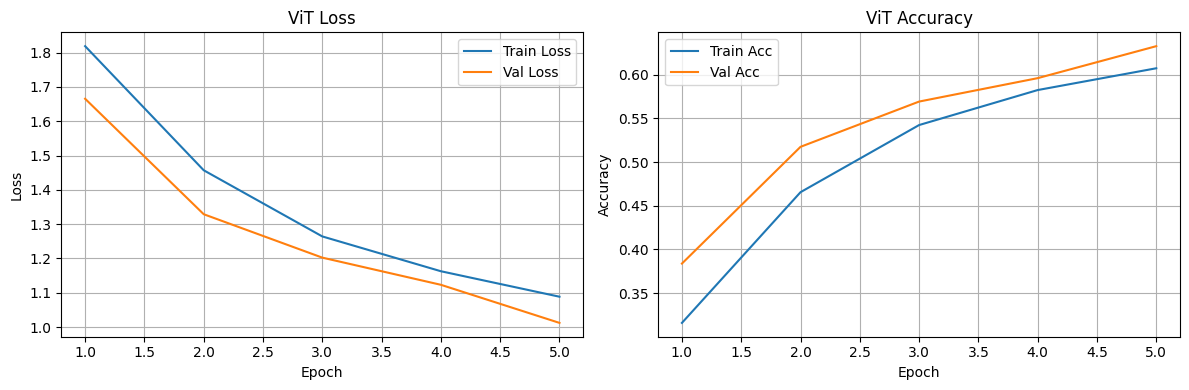

[ViT] Test Loss: 0.9886, Test Acc: 0.6463
[ViT] Metrics - Acc: 0.6463, Precision: 0.6463, Recall: 0.6463, F1: 0.6376

[ViT] Classification Report:
              precision    recall  f1-score   support

    airplane      0.651     0.719     0.683      1000
  automobile      0.768     0.705     0.735      1000
        bird      0.573     0.450     0.504      1000
         cat      0.594     0.288     0.388      1000
        deer      0.511     0.696     0.589      1000
         dog      0.583     0.557     0.570      1000
        frog      0.651     0.793     0.715      1000
       horse      0.691     0.696     0.694      1000
        ship      0.753     0.810     0.780      1000
       truck      0.688     0.749     0.717      1000

    accuracy                          0.646     10000
   macro avg      0.646     0.646     0.638     10000
weighted avg      0.646     0.646     0.638     10000



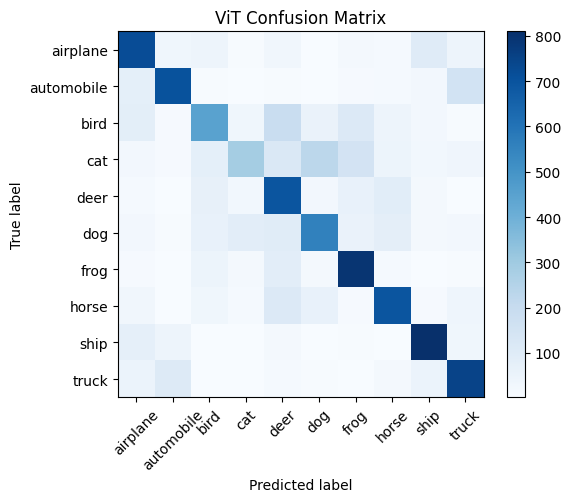

In [10]:

# =====================================
# Cell 9: ViT loss/accuracy plots and test metrics
# =====================================

plot_history(history_vit, title_prefix="ViT")

test_loss_vit, test_acc_vit, y_true_vit, y_pred_vit = eval_model(vit_model, test_loader, criterion_vit)
acc_vit, prec_vit, rec_vit, f1_vit, cm_vit = compute_metrics(y_true_vit, y_pred_vit, num_classes=10)

print(f"[ViT] Test Loss: {test_loss_vit:.4f}, Test Acc: {test_acc_vit:.4f}")
print(f"[ViT] Metrics - Acc: {acc_vit:.4f}, Precision: {prec_vit:.4f}, Recall: {rec_vit:.4f}, F1: {f1_vit:.4f}")

print("\n[ViT] Classification Report:")
print(classification_report(y_true_vit, y_pred_vit, target_names=class_names, digits=3))

plt.figure(figsize=(6, 5))
plt.imshow(cm_vit, interpolation="nearest", cmap="Blues")
plt.title("ViT Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


## 5. Transfer Learning with ResNet-18

We now use a pretrained ResNet-18, replace the final layer with a 10-class head, and fine-tune it on CIFAR-10.

In [11]:

# =====================================
# Cell 10: Define ResNet-18 transfer learning model
# =====================================

resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
# Adjust first conv layer if needed (for CIFAR-10 32x32, default works fine)

# Replace final layer
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, 10)

resnet_model = resnet_model.to(device)

# Option 1: Freeze all but last layer
for name, param in resnet_model.named_parameters():
    param.requires_grad = False
for param in resnet_model.fc.parameters():
    param.requires_grad = True

print("ResNet-18 parameters (trainable only):", count_parameters(resnet_model))


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 144MB/s]

ResNet-18 parameters (trainable only): 5130


In [12]:

# =====================================
# Cell 11: Train ResNet-18 (transfer learning)
# =====================================

N_EPOCHS_RESNET = 5  # increase if you have more time
LR_RESNET = 1e-3

optimizer_resnet = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=LR_RESNET)
criterion_resnet = nn.CrossEntropyLoss()

history_resnet = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "epoch_time": [],
}

for epoch in range(1, N_EPOCHS_RESNET + 1):
    start = time.time()
    train_loss, train_acc = train_one_epoch(resnet_model, train_loader, optimizer_resnet, criterion_resnet)
    val_loss, val_acc, _, _ = eval_model(resnet_model, val_loader, criterion_resnet)

    history_resnet["train_loss"].append(train_loss)
    history_resnet["train_acc"].append(train_acc)
    history_resnet["val_loss"].append(val_loss)
    history_resnet["val_acc"].append(val_acc)
    history_resnet["epoch_time"].append(time.time() - start)

    print(
        f"[ResNet] Epoch {epoch}/{N_EPOCHS_RESNET} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
        f"Time: {history_resnet['epoch_time'][-1]:.1f}s"
    )


[ResNet] Epoch 1/5 | Train Loss: 1.8656, Train Acc: 0.3399 | Val Loss: 1.7441, Val Acc: 0.3928 | Time: 18.2s
[ResNet] Epoch 2/5 | Train Loss: 1.7264, Train Acc: 0.3937 | Val Loss: 1.6956, Val Acc: 0.4092 | Time: 18.5s
[ResNet] Epoch 3/5 | Train Loss: 1.7005, Train Acc: 0.4046 | Val Loss: 1.7044, Val Acc: 0.4104 | Time: 19.7s
[ResNet] Epoch 4/5 | Train Loss: 1.6845, Train Acc: 0.4088 | Val Loss: 1.6773, Val Acc: 0.4096 | Time: 18.8s
[ResNet] Epoch 5/5 | Train Loss: 1.6816, Train Acc: 0.4102 | Val Loss: 1.6837, Val Acc: 0.4076 | Time: 18.8s


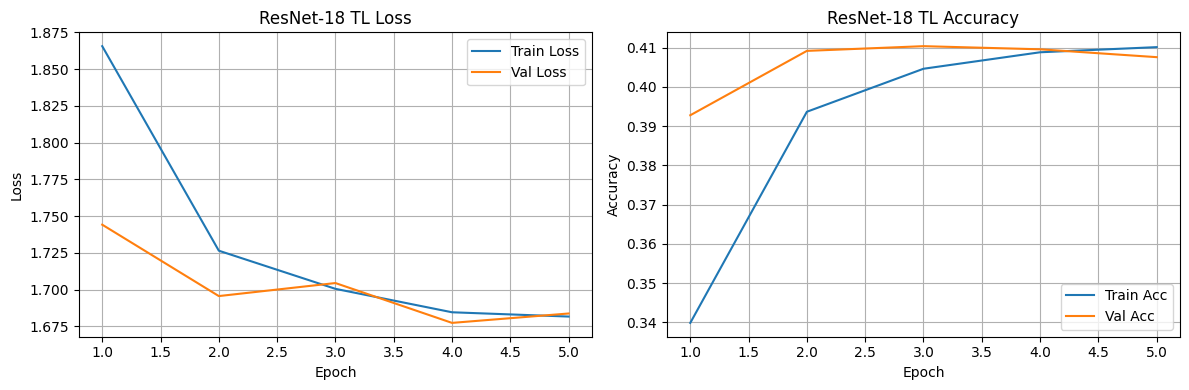

[ResNet] Test Loss: 1.7149, Test Acc: 0.4030
[ResNet] Metrics - Acc: 0.4030, Precision: 0.4071, Recall: 0.4030, F1: 0.4008

[ResNet] Classification Report:
              precision    recall  f1-score   support

    airplane      0.419     0.378     0.397      1000
  automobile      0.470     0.410     0.438      1000
        bird      0.326     0.325     0.325      1000
         cat      0.345     0.357     0.351      1000
        deer      0.400     0.467     0.431      1000
         dog      0.408     0.299     0.345      1000
        frog      0.417     0.550     0.474      1000
       horse      0.478     0.407     0.440      1000
        ship      0.368     0.499     0.424      1000
       truck      0.440     0.338     0.382      1000

    accuracy                          0.403     10000
   macro avg      0.407     0.403     0.401     10000
weighted avg      0.407     0.403     0.401     10000



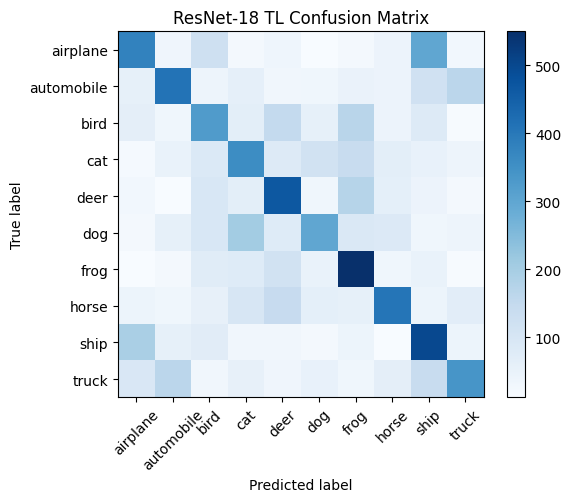

In [13]:

# =====================================
# Cell 12: ResNet loss/accuracy plots and test metrics
# =====================================

plot_history(history_resnet, title_prefix="ResNet-18 TL")

test_loss_resnet, test_acc_resnet, y_true_resnet, y_pred_resnet = eval_model(
    resnet_model, test_loader, criterion_resnet
)
acc_resnet, prec_resnet, rec_resnet, f1_resnet, cm_resnet = compute_metrics(
    y_true_resnet, y_pred_resnet, num_classes=10
)

print(f"[ResNet] Test Loss: {test_loss_resnet:.4f}, Test Acc: {test_acc_resnet:.4f}")
print(
    f"[ResNet] Metrics - Acc: {acc_resnet:.4f}, "
    f"Precision: {prec_resnet:.4f}, Recall: {rec_resnet:.4f}, F1: {f1_resnet:.4f}"
)

print("\n[ResNet] Classification Report:")
print(classification_report(y_true_resnet, y_pred_resnet, target_names=class_names, digits=3))

plt.figure(figsize=(6, 5))
plt.imshow(cm_resnet, interpolation="nearest", cmap="Blues")
plt.title("ResNet-18 TL Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


## 6. Model Comparison & Inference Speed

We now compare the three models on key dimensions: accuracy, precision, recall, F1, parameters, and inference speed.

In [14]:

# =====================================
# Cell 13: Summarize metrics and measure inference speed
# =====================================

summary = {
    "Model": ["CNN", "ViT", "ResNet-18 TL"],
    "Params": [
        count_parameters(cnn_model),
        count_parameters(vit_model),
        count_parameters(resnet_model),
    ],
    "Test_Acc": [acc_cnn, acc_vit, acc_resnet],
    "Test_Precision": [prec_cnn, prec_vit, prec_resnet],
    "Test_Recall": [rec_cnn, rec_vit, rec_resnet],
    "Test_F1": [f1_cnn, f1_vit, f1_resnet],
    "Avg_Epoch_Time": [
        np.mean(history_cnn["epoch_time"]),
        np.mean(history_vit["epoch_time"]),
        np.mean(history_resnet["epoch_time"]),
    ],
}

import pandas as pd

df_summary = pd.DataFrame(summary)
display(df_summary)

# Inference speed measurement (on a subset of test set)
def measure_inference_time(model, dataloader, num_batches=10):
    model.eval()
    times = []
    n_samples = 0
    with torch.no_grad():
        for i, (inputs, _) in enumerate(dataloader):
            if i >= num_batches:
                break
            inputs = inputs.to(device)
            start = time.time()
            _ = model(inputs)
            times.append(time.time() - start)
            n_samples += inputs.size(0)
    total_time = sum(times)
    return total_time, n_samples, total_time / n_samples

for name, model in [("CNN", cnn_model), ("ViT", vit_model), ("ResNet-18 TL", resnet_model)]:
    total_t, n_s, per_sample = measure_inference_time(model, test_loader, num_batches=20)
    print(
        f"[{name}] Inference on {n_s} images took {total_t:.4f}s "
        f"({per_sample*1000:.3f} ms/image)"
    )


,Model,Params,Test_Acc,Test_Precision,Test_Recall,Test_F1,Avg_Epoch_Time
0,CNN,620810,0.7113,0.711630,0.7113,0.709745,18.349740
1,ViT,3195146,0.6463,0.646266,0.6463,0.637567,38.350406
2,ResNet-18 TL,5130,0.4030,0.407131,0.4030,0.400790,18.812671


[CNN] Inference on 2560 images took 0.0565s (0.022 ms/image)
[ViT] Inference on 2560 images took 0.1295s (0.051 ms/image)
[ResNet-18 TL] Inference on 2560 images took 0.1947s (0.076 ms/image)


## 7. Simple Gradio UI for CIFAR-10 Classification

We build an interactive interface where the user can upload an image, choose a model, and see the predicted CIFAR-10 class.

In [16]:

# =====================================
# Cell 14: Gradio-based prediction UI
# =====================================

# We'll use the same normalization as test_transform
inv_mean = [-m/s for m, s in zip(CIFAR10_MEAN, CIFAR10_STD)]
inv_std = [1/s for s in CIFAR10_STD]

def preprocess_image_for_model(img):
    # img is a PIL.Image
    img = img.resize((32, 32))
    tensor = transforms.ToTensor()(img)
    tensor = transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)(tensor)
    return tensor.unsqueeze(0)  # (1, 3, 32, 32)

MODEL_DICT = {
    "CNN": cnn_model,
    "ViT": vit_model,
    "ResNet-18 TL": resnet_model,
}

def predict_image(model_name, img):
    if img is None:
        return "Please upload an image."
    model = MODEL_DICT[model_name]
    model.eval()
    with torch.no_grad():
        x = preprocess_image_for_model(img).to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    top_idx = int(np.argmax(probs))
    pred_class = class_names[top_idx]
    conf = probs[top_idx]
    return f"Predicted: {pred_class} (confidence: {conf*100:.2f}%)"

demo = gr.Interface(
    fn=predict_image,
    inputs=[
        gr.Radio(list(MODEL_DICT.keys()), label="Model", value="ResNet-18 TL"),
        gr.Image(type="pil", label="Upload CIFAR-10-like image (32x32 or any)"),
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="CIFAR-10 Image Classification (CNN, ViT, ResNet-18 TL)",
    description="Upload an image and choose a model to see the predicted CIFAR-10 class.",
)

# To launch in Colab:
demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4940059ded490a2cee.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
